Mean mu: 55.189296875
-----
Pixel row 0.0 col 0.0, mu: 48.14, T_up_tuner: 1, TDAC_tuner: 7, Mu distance: 7.05
-----
Pixel row 0.0 col 1.0, mu: 65.21, T_up_tuner: 0, TDAC_tuner: 11, Mu distance: -10.02
-----
Pixel row 0.0 col 2.0, mu: 52.05, T_up_tuner: 1, TDAC_tuner: 3, Mu distance: 3.14
-----
Pixel row 0.0 col 3.0, mu: 62.86, T_up_tuner: 0, TDAC_tuner: 8, Mu distance: -7.67
-----
Pixel row 0.0 col 4.0, mu: 48.69, T_up_tuner: 1, TDAC_tuner: 7, Mu distance: 6.5
-----
Pixel row 0.0 col 5.0, mu: 48.9, T_up_tuner: 1, TDAC_tuner: 6, Mu distance: 6.29
-----
Pixel row 0.0 col 6.0, mu: 41.97, T_up_tuner: 1, TDAC_tuner: 14, Mu distance: 13.22
-----
Pixel row 0.0 col 7.0, mu: 65.93, T_up_tuner: 0, TDAC_tuner: 11, Mu distance: -10.74
-----
Pixel row 1.0 col 0.0, mu: 62.3, T_up_tuner: 0, TDAC_tuner: 7, Mu distance: -7.11
-----
Pixel row 1.0 col 1.0, mu: 51.51, T_up_tuner: 1, TDAC_tuner: 4, Mu distance: 3.68
-----
Pixel row 1.0 col 2.0, mu: 64.4, T_up_tuner: 0, TDAC_tuner: 10, Mu distance: -9.21
--

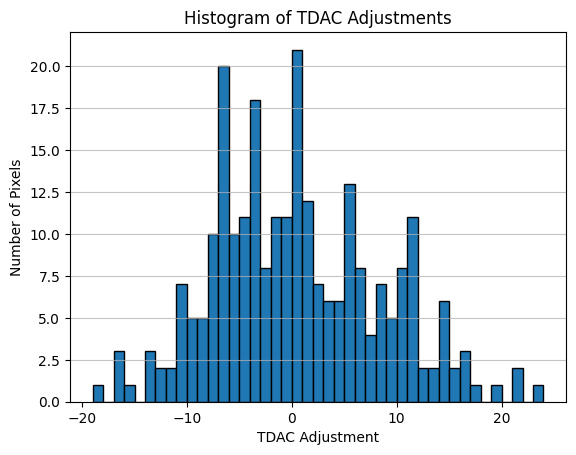

In [5]:
import pandas as pd


# apri il file scurve_fit_results.csv e mostra le prime righe
verify_df = pd.read_csv("scurve_tdac0_fit_results.csv")


# considera il fit lineare calcolato da Fit results: mu = 0.90 * TDAC + 53.85
def tdac_to_mu(tdac_code):
    return 0.90 * tdac_code + 53.85

def mu_to_tdac(mu):
    return (mu - 53.85) / 0.90


def tune(target_mu, pixel_mu):
    tup=0
    mu_distance = round(target_mu - pixel_mu,2)
    tdac_adjustment = int(mu_distance / 0.90)

    if tdac_adjustment > 0:
        tup = 1


    #print(f"Target mu: {target_mu}, Pixel mu: {pixel_mu}")
    #print(f"Mu distance: {mu_distance}, TDAC adjustment: {tdac_adjustment}")

    return tup, abs(tdac_adjustment), mu_distance


# da verify_df calcola la media delle mu
mean_mu = verify_df['mu'].mean()
print(f"Mean mu: {mean_mu}")

# per ogni pixel del file calcola il tdac adjustment per portare la mu alla media
tdac_codes_tuned = []
for index, row in verify_df.iterrows():
    pixel_mu = row['mu']
    t_up_tuner, tdac_tuner, mu_distance = tune(mean_mu, pixel_mu)
    tdac_codes_tuned.append((int(row["row"]), int(row["col"]), t_up_tuner, tdac_tuner))
    print("-----")
    print(f"Pixel row {row['row']} col {row['col']}, mu: {pixel_mu}, T_up_tuner: {t_up_tuner}, TDAC_tuner: {tdac_tuner}, Mu distance: {mu_distance}")

# plot istogramma degli aggiustamenti TDAC e tup, considerando tdac_negativo se associato a tup=1
import matplotlib.pyplot as plt
# tdac_codes_tuned contiene tuple (row, col, tup, tdac) — decomponiamo correttamente
tdac_adjustments = [tdac if tup == 0 else -tdac for (_, _, tup, tdac) in tdac_codes_tuned]
plt.hist(tdac_adjustments, bins=range(min(tdac_adjustments), max(tdac_adjustments) + 1, 1), edgecolor='black')
plt.title("Histogram of TDAC Adjustments")
plt.xlabel("TDAC Adjustment")
plt.ylabel("Number of Pixels")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [6]:
# crea un file tsv con le colonne: pixel_index, t_up_tuner, tdac_tuner
with open("tdac_tuning_results.tsv", "w") as f:
    f.write("row\tcol\tt_up_tuner\ttdac_tuner\n")
    for index, (row, col, t_up_tuner, tdac_tuner) in enumerate(tdac_codes_tuned):
        f.write(f"{row}\t{col}\t{t_up_tuner}\t{tdac_tuner}\n")